In [1]:
# Problem statement
""" A restaurant consolidator is looking to revamp the B2C portal using intelligent automation tech.
This requires a different matrix to identify the star restaurants and generate recommendations. 
To make sure an effective model can be achieved, it is important to understand the behavior of the data in hand.
There are 2 datasets, data and Country-Code. Dataset data has 19 attributes and Country-Code has two attributes.
You are required to determine certain matrices to identify the star restaurants and generate recommendations.""" 

' A restaurant consolidator is looking to revamp the B2C portal using intelligent automation tech.\nThis requires a different matrix to identify the star restaurants and generate recommendations. \nTo make sure an effective model can be achieved, it is important to understand the behavior of the data in hand.\nThere are 2 datasets, data and Country-Code. Dataset data has 19 attributes and Country-Code has two attributes.\nYou are required to determine certain matrices to identify the star restaurants and generate recommendations.'

In [2]:
# Find Out best Restaurant accross the world and which cuisine is the best cuisine , how many franchise have this restaurant 
#  number of cuisines, cost, delivery option, etc. to find out insights  from data i am doing some specific tasks.

#Importing, Understanding, and Inspecting Data:
# 1. Perform preliminary data inspection and report the findings as the structure of the data, missing values, duplicates, etc.
# 2. Based on the findings from the previous questions, identify duplicates and remove them


# import Libraries

In [3]:
import numpy as np                            
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Loading the dataset

In [4]:
df1 = pd.read_excel("data.xlsx")

In [5]:
# Check data set
df1.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243


In [6]:
# load 2nd dataset
df2 = pd.read_excel("Country-Code.xlsx")

In [7]:
# check 2nd data set
df2.head()

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [8]:
# as we can see we have 2 data sets to perform further steps we have to merge these two dataset to get insights from data 
# and in these datasets we have Country code common column .we are doing left join  because in left table we have all data and
# in right table we have common data 

dfm = pd.merge(df1,df2 , on = "Country Code" , how = "left")
dfm.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498,Indonesia
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873,Indonesia
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605,Indonesia
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,Indonesia
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243,Indonesia


# both data set merge here we can see at last we have country column

In [9]:
# to check all columns
dfm.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes', 'Country'],
      dtype='object')

In [10]:
# for better understanding we are going to replace white space with (_) in column name
dfm.columns = dfm.columns.str.replace(" " , "_")
dfm.columns

Index(['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address',
       'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average_Cost_for_two', 'Currency', 'Has_Table_booking',
       'Has_Online_delivery', 'Price_range', 'Aggregate_rating',
       'Rating_color', 'Rating_text', 'Votes', 'Country'],
      dtype='object')

In [11]:
# to check all info from data 
dfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant_ID         9551 non-null   int64  
 1   Restaurant_Name       9550 non-null   object 
 2   Country_Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality_Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average_Cost_for_two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has_Table_booking     9551 non-null   object 
 13  Has_Online_delivery   9551 non-null   object 
 14  Price_range           9551 non-null   int64  
 15  Aggregate_rating     

In [12]:
# Data Cleaning

In [13]:
# check null values
dfm.isnull().sum()

Restaurant_ID           0
Restaurant_Name         1
Country_Code            0
City                    0
Address                 0
Locality                0
Locality_Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average_Cost_for_two    0
Currency                0
Has_Table_booking       0
Has_Online_delivery     0
Price_range             0
Aggregate_rating        0
Rating_color            0
Rating_text             0
Votes                   0
Country                 0
dtype: int64

# Restaurant_Name and Cuisines we have null values

In [14]:
# for Restaurant_Name Check for what Restaurant it belongs to 
dfm[dfm["Restaurant_Name"].isnull()]

,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,Average_Cost_for_two,Currency,Has_Table_booking,Has_Online_delivery,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes,Country
1646,113702,NaN,1,Ahmedabad,"Opposite Sindhu Bhawan, Bodakdev, Ahmedabad",Bodakdev,"Bodakdev, Ahmedabad",72.501764,23.040163,"North Indian, Continental, Mexican, Italian",800,Indian Rupees(Rs.),No,No,3,4.1,Green,Very Good,769,India


In [15]:
# we need to drop this record from data set and as well as reset the index
dfm.dropna( axis = 0 , subset = ["Restaurant_Name"] , inplace = True)
dfm.reset_index(drop = True , inplace = True)

# After operations like filtering, concatenation, or merging, the index may no longer be sequential.
#This method helps re-establish a clean, sequential index.

dfm[dfm["Restaurant_Name"].isnull()]

,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,Average_Cost_for_two,Currency,Has_Table_booking,Has_Online_delivery,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes,Country


In [16]:
# This record is deleted permanently 

In [17]:
# again check null values
dfm.isnull().sum()

Restaurant_ID           0
Restaurant_Name         0
Country_Code            0
City                    0
Address                 0
Locality                0
Locality_Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average_Cost_for_two    0
Currency                0
Has_Table_booking       0
Has_Online_delivery     0
Price_range             0
Aggregate_rating        0
Rating_color            0
Rating_text             0
Votes                   0
Country                 0
dtype: int64

In [18]:
# now in Cuisines we have null values
dfm[dfm["Cuisines"].isnull()]

,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,Average_Cost_for_two,Currency,Has_Table_booking,Has_Online_delivery,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes,Country
9082,17374552,Corkscrew Cafe,216,Gainesville,"51 W Main St, Dahlonega, GA 30533",Dahlonega,"Dahlonega, Gainesville",-83.985800,34.531800,NaN,40,Dollar($),No,No,3,3.9,Yellow,Good,209,United States
9085,17501439,Dovetail,216,Macon,"543 Cherry St, Macon, GA 31201",Macon,"Macon, Macon",-83.627979,32.836410,NaN,40,Dollar($),No,No,3,3.8,Yellow,Good,102,United States
9093,17059060,Hillstone,216,Orlando,"215 South Orlando Avenue, Winter Park, FL 32789",Winter Park,"Winter Park, Orlando",-81.365260,28.596682,NaN,40,Dollar($),No,No,3,4.4,Green,Very Good,1158,United States
9405,17284158,Jimmie's Hot Dogs,216,Albany,"204 S Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.153400,31.575100,NaN,10,Dollar($),No,No,1,3.9,Yellow,Good,160,United States
9493,17142698,Leonard's Bakery,216,Rest of Hawaii,"933 Kapahulu Ave, Honolulu, HI 96816",Kaimuki,"Kaimuki, Rest of Hawaii",-157.813432,21.284586,NaN,10,Dollar($),No,No,1,4.7,Dark Green,Excellent,707,United States
9503,17616465,Tybee Island Social Club,216,Savannah,"1311 Butler Ave, Tybee Island, GA 31328",Tybee Island,"Tybee Island, Savannah",-80.848297,31.995810,NaN,10,Dollar($),No,No,1,3.9,Yellow,Good,309,United States
9532,17284105,Cookie Shoppe,216,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154000,31.577200,NaN,0,Dollar($),No,No,1,3.4,Orange,Average,34,United States
9534,17284211,Pearly's Famous Country Cookng,216,Albany,"814 N Slappey Blvd, Albany, GA 31701",Albany,"Albany, Albany",-84.175900,31.588200,NaN,0,Dollar($),No,No,1,3.4,Orange,Average,36,United States
9538,17606621,HI Lite Bar & Lounge,216,Miller,"109 N Broadway Ave, Miller, SD 57362",Miller,"Miller, Miller",-98.989100,44.515800,NaN,0,Dollar($),No,No,1,3.4,Orange,Average,11,United States


In [19]:
# we have 9 records with null values we have to fill this with "Others" Because we cannot drop all 9 values 
# it will efect on our end result 
dfm["Cuisines"].fillna("Others")

0                                    Italian, Continental
1                              Asian, Indonesian, Western
2                                         Sushi, Japanese
3                                                Japanese
4                                         French, Western
                              ...                        
9545                     Chinese, North Indian, Fast Food
9546                         Indian, Chinese, Continental
9547    Cafe, Continental, Desserts, Ice Cream, Italia...
9548                                          Street Food
9549                                Chinese, North Indian
Name: Cuisines, Length: 9550, dtype: object

In [20]:
dfm[dfm["Cuisines"].isnull()] 
# we can see null values remain same after filling we need to save this permanently  with (inplace = True)

,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,Average_Cost_for_two,Currency,Has_Table_booking,Has_Online_delivery,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes,Country
9082,17374552,Corkscrew Cafe,216,Gainesville,"51 W Main St, Dahlonega, GA 30533",Dahlonega,"Dahlonega, Gainesville",-83.985800,34.531800,NaN,40,Dollar($),No,No,3,3.9,Yellow,Good,209,United States
9085,17501439,Dovetail,216,Macon,"543 Cherry St, Macon, GA 31201",Macon,"Macon, Macon",-83.627979,32.836410,NaN,40,Dollar($),No,No,3,3.8,Yellow,Good,102,United States
9093,17059060,Hillstone,216,Orlando,"215 South Orlando Avenue, Winter Park, FL 32789",Winter Park,"Winter Park, Orlando",-81.365260,28.596682,NaN,40,Dollar($),No,No,3,4.4,Green,Very Good,1158,United States
9405,17284158,Jimmie's Hot Dogs,216,Albany,"204 S Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.153400,31.575100,NaN,10,Dollar($),No,No,1,3.9,Yellow,Good,160,United States
9493,17142698,Leonard's Bakery,216,Rest of Hawaii,"933 Kapahulu Ave, Honolulu, HI 96816",Kaimuki,"Kaimuki, Rest of Hawaii",-157.813432,21.284586,NaN,10,Dollar($),No,No,1,4.7,Dark Green,Excellent,707,United States
9503,17616465,Tybee Island Social Club,216,Savannah,"1311 Butler Ave, Tybee Island, GA 31328",Tybee Island,"Tybee Island, Savannah",-80.848297,31.995810,NaN,10,Dollar($),No,No,1,3.9,Yellow,Good,309,United States
9532,17284105,Cookie Shoppe,216,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154000,31.577200,NaN,0,Dollar($),No,No,1,3.4,Orange,Average,34,United States
9534,17284211,Pearly's Famous Country Cookng,216,Albany,"814 N Slappey Blvd, Albany, GA 31701",Albany,"Albany, Albany",-84.175900,31.588200,NaN,0,Dollar($),No,No,1,3.4,Orange,Average,36,United States
9538,17606621,HI Lite Bar & Lounge,216,Miller,"109 N Broadway Ave, Miller, SD 57362",Miller,"Miller, Miller",-98.989100,44.515800,NaN,0,Dollar($),No,No,1,3.4,Orange,Average,11,United States


In [21]:
dfm["Cuisines"].fillna("Others", inplace = True)

/var/folders/77/ff1vcqz119lgxg8cqj450s200000gn/T/ipykernel_8259/3815031913.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfm["Cuisines"].fillna("Others", inplace = True)


In [22]:
dfm.isnull().sum()

Restaurant_ID           0
Restaurant_Name         0
Country_Code            0
City                    0
Address                 0
Locality                0
Locality_Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average_Cost_for_two    0
Currency                0
Has_Table_booking       0
Has_Online_delivery     0
Price_range             0
Aggregate_rating        0
Rating_color            0
Rating_text             0
Votes                   0
Country                 0
dtype: int64

In [23]:
# all null values removed

In [24]:
dfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9550 entries, 0 to 9549
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant_ID         9550 non-null   int64  
 1   Restaurant_Name       9550 non-null   object 
 2   Country_Code          9550 non-null   int64  
 3   City                  9550 non-null   object 
 4   Address               9550 non-null   object 
 5   Locality              9550 non-null   object 
 6   Locality_Verbose      9550 non-null   object 
 7   Longitude             9550 non-null   float64
 8   Latitude              9550 non-null   float64
 9   Cuisines              9550 non-null   object 
 10  Average_Cost_for_two  9550 non-null   int64  
 11  Currency              9550 non-null   object 
 12  Has_Table_booking     9550 non-null   object 
 13  Has_Online_delivery   9550 non-null   object 
 14  Price_range           9550 non-null   int64  
 15  Aggregate_rating     

In [25]:
dfm.shape

(9550, 20)

In [26]:
dfm.duplicated().sum()

np.int64(0)

In [27]:
# we have cleaned data , no null value ,no duplicate values 

In [28]:
""" Performing EDA:
3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants
4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence
5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking
6. Find out the percentage of restaurants providing online delivery
7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver 
"""

' Performing EDA:\n3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants\n4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence\n5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking\n6. Find out the percentage of restaurants providing online delivery\n7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver \n'

In [29]:
dfm.columns

Index(['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address',
       'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average_Cost_for_two', 'Currency', 'Has_Table_booking',
       'Has_Online_delivery', 'Price_range', 'Aggregate_rating',
       'Rating_color', 'Rating_text', 'Votes', 'Country'],
      dtype='object')

In [30]:
# Explore the geographical distribution of the restaurants. Finding out the cities with maximum / minimum number of restaurants

# for geographical distribution we need Country_Code , Country_Name and  total no. Restaurants in each country to find maximum and minimum
# number of restaurants 
cntry_dist = dfm.groupby(["Country_Code" , "Country"]).agg(Count = ("Restaurant_ID","count"))
cntry_dist.sort_values(by = "Count" , ascending = False)

,,Count
Country_Code,Country,
1,India,8651
216,United States,434
215,United Kingdom,80
30,Brazil,60
189,South Africa,60
214,UAE,60
148,New Zealand,40
208,Turkey,34
14,Australia,24


In [31]:
# India has the Heighest Number of Restaurents with 8651 Restaurants

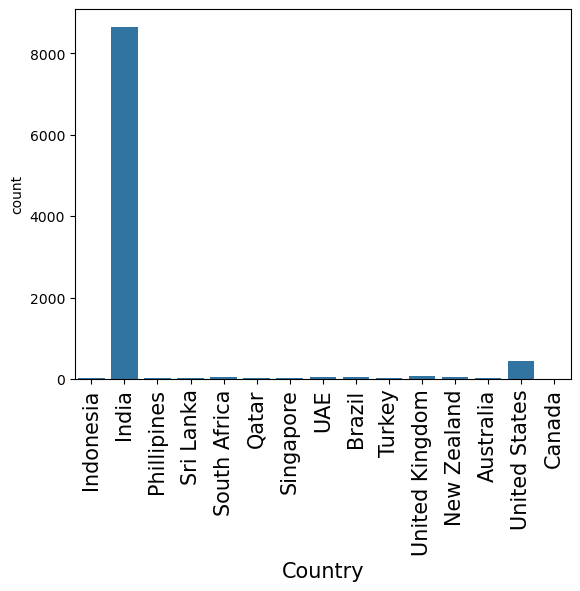

In [32]:
# to visualize this we create countplot 
sns.countplot( x = "Country" , data = dfm)
plt.xticks(size = 15)
plt.xticks(rotation = 90)
plt.xlabel("Country", size = 15)
plt.show()

<Axes: ylabel='Country_Code,Country'>

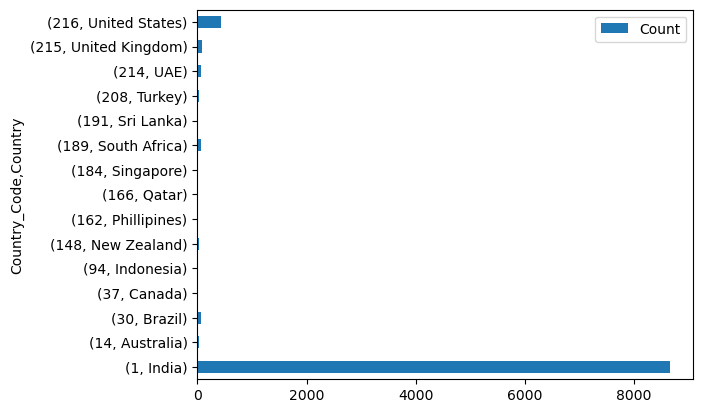

In [33]:
cntry_dist.plot(kind = "barh")

In [34]:
# Finding out the cities with maximum / minimum number of restaurants

# Now we know India has Heighest Number of Restaurants 
# here we are going to find max and min Restaurants in every city in every Country 

city_dist = dfm.groupby(["Country" , "City"]).agg(Count = ("Restaurant_ID" , "count"))
city_dist.sort_values(by = "Count",ascending = False)

Count
Country       City                 
India         New Delhi        5473
              Gurgaon          1118
              Noida            1080
              Faridabad         251
              Ghaziabad          25
...                             ...
              Panchkula           1
Australia     Balingup            1
Indonesia     Bandung             1
Phillipines   Quezon City         1
United States Winchester Bay      1

[141 rows x 1 columns]

In [35]:
# City with Max Restaurant is 5473
# city with min value is 1
city_dist.describe()

,Count
count,141.000000
mean,67.730496
std,476.723952
min,1.000000
25%,1.000000
50%,20.000000
75%,20.000000
max,5473.000000


# We observe that in India ,New Delhi has maximum number of Restaurants 

In [36]:
# we also observe that multiple cities is multiple countries has only 1 Restaurants

min_cnt_rest = city_dist[city_dist["Count"] == 1]
min_cnt_rest.info()
min_cnt_rest

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 46 entries, ('Australia', 'Armidale') to ('United States', 'Winchester Bay')
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Count   46 non-null     int64
dtypes: int64(1)
memory usage: 2.3+ KB


Count
Country       City                   
Australia     Armidale              1
              Balingup              1
              Beechworth            1
              Dicky Beach           1
              East Ballina          1
              Flaxton               1
              Forrest               1
              Huskisson             1
              Inverloch             1
              Lakes Entrance        1
              Lorn                  1
              Macedon               1
              Mayfield              1
              Middleton Beach       1
              Montville             1
              Palm Cove             1
              Paynesville           1
              Penola                1
              Phillip Island        1
              Tanunda               1
              Trentham East         1
              Victor Harbor         1
Canada        Chatham-Kent          1
              Consort               1
              Vineland Station      1
              Yorkton               1
India         Mohali                1
              Panchkula             1
Indonesia     Bandung               1
Phillipines   Quezon City           1
              Tagaytay City         1
South Africa  Randburg              1
United States Clatskanie            1
              Cochrane              1
              Fernley               1
              Lakeview              1
              Lincoln               1
              Mc Millan             1
              Miller                1
              Monroe                1
              Ojo Caliente          1
              Potrero               1
              Princeton             1
              Vernonia              1
              Weirton               1
              Winchester Bay        1

# we got to know that there are 46 cities in different countries with 1 restaurants

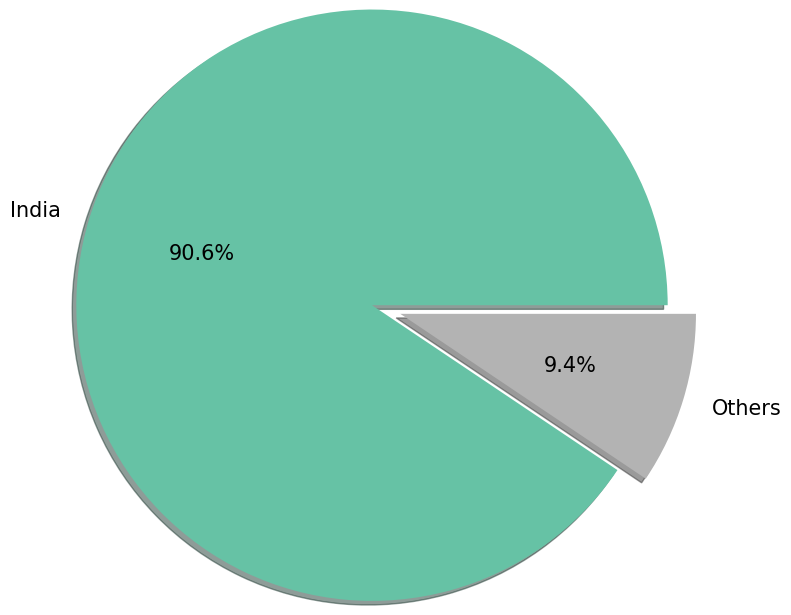

In [37]:
# visual representation India has the Heighest Number of Restaurents in percentile

restaurant_counts = pd.Series()
restaurant_counts['India'] = len(dfm[dfm.Country == 'India'])
restaurant_counts['Others'] = len(dfm[dfm.Country != 'India'])
restaurant_counts.plot.pie(radius = 2,autopct = '%1.1f%%' , textprops = {'size':15 }, explode
= [0.1,0.1], shadow = True, cmap ='Set2')
plt.xticks(size = 8, rotation = 10)
plt.ylabel('')
plt.show()

# From above Pi chart we can say that The country India alone has the 90.6% of total restaurants count and other 14 countries together holds only 9.4%
# Analysing data from India should give us a pretty accurate representation of the entire data.

# -------------------------------------------------------------------------------

In [38]:
# Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence

In [39]:
# Explore the franchise with most national presence
franch_dist = dfm.groupby(['Restaurant_Name','Country']).agg(Count = ('Country','count'))
franch_dist.sort_values(by='Count',ascending=False)

,,Count
Restaurant_Name,Country,
Cafe Coffee Day,India,83
Domino's Pizza,India,79
Subway,India,63
Green Chick Chop,India,51
McDonald's,India,48
...,...,...
Gibson's Gourmet Burgers & Ribs,South Africa,1
Giapo,New Zealand,1
Giani's di Hatti,India,1


# Cafe Coffe day has most national prsesence

In [40]:
franch_dist.describe()

,Count
count,7472.000000
mean,1.278105
std,2.165675
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,83.000000


/var/folders/77/ff1vcqz119lgxg8cqj450s200000gn/T/ipykernel_8259/3778768277.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  value = vc[i]


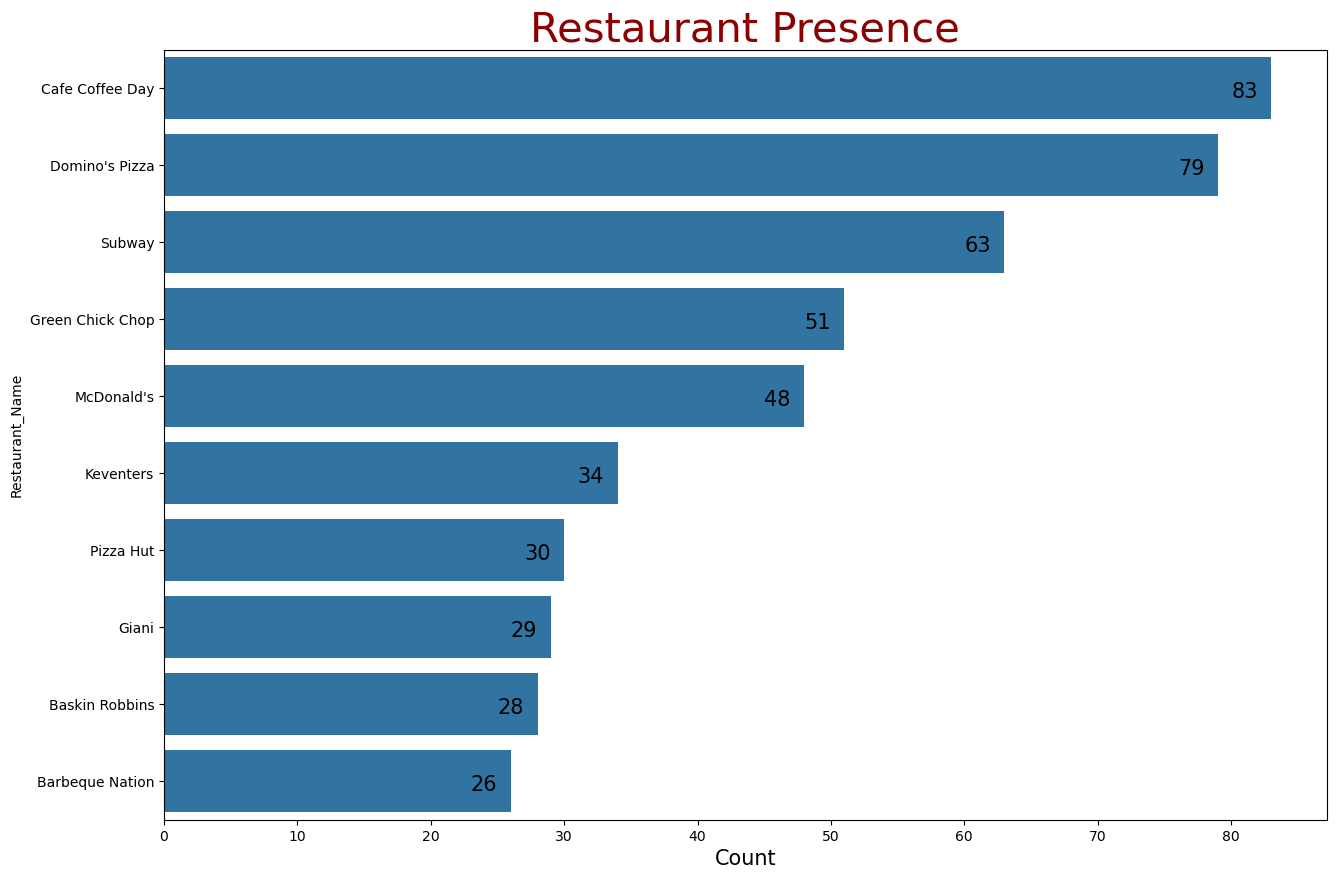

In [41]:
plt.figure(figsize = (15,10))
vc = dfm.Restaurant_Name.value_counts()[:10]
g = sns.barplot(y = vc.index, x = vc.values)
for i in range(10):
 value = vc[i]
 g.text(x = value - 2,y = i +0.125 , s = value, color='black', ha="center",fontsize = 15)
g.set_xlabel('Count', fontsize = 15)
g.set_title('Restaurant Presence', fontsize = 30, color = 'darkred')
plt.show()

# We can see Cafe Coffee day Has most Restaurant Presence

In [42]:
# Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking

dfm1 = dfm.copy()
dfm1.columns

Index(['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address',
       'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average_Cost_for_two', 'Currency', 'Has_Table_booking',
       'Has_Online_delivery', 'Price_range', 'Aggregate_rating',
       'Rating_color', 'Rating_text', 'Votes', 'Country'],
      dtype='object')

In [43]:
# to get ratio between restaurants that allow table booking and that do not we need 
# "Has_Table_Booking" and "Has_Online_Delivery" columns 
# we use.getdummy method (The dummy variables take on the value “1” if the original categorical variable was that level or “0” if not)
# get_dummies : Converts categorical variables into numerical format (one-hot encoding). 
# drop_first=True : Removes the first category to avoid redundancy .

dummy = ['Has_Table_booking','Has_Online_delivery']
dfm1 = pd.get_dummies(dfm1,columns=dummy,drop_first=True)
dfm1.head()
# 0 indicates 'NO'
# 1 indicates 'YES'

,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,Average_Cost_for_two,Currency,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes,Country,Has_Table_booking_Yes,Has_Online_delivery_Yes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),3,4.1,Green,Very Good,1498,Indonesia,False,False
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),3,4.6,Dark Green,Excellent,873,Indonesia,False,False
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),3,4.9,Dark Green,Excellent,605,Indonesia,False,False
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),3,4.2,Green,Very Good,395,Indonesia,False,False
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),3,4.3,Green,Very Good,243,Indonesia,False,False


In [44]:
#Ratio between restaurants allowing table booking and those which don't

table_booking = dfm1[dfm1['Has_Table_booking_Yes']==1]['Restaurant_ID'].count()
table_nbooking =dfm1[dfm1['Has_Table_booking_Yes']==0]['Restaurant_ID'].count()
print('Ratio between restaurants that allow table booking vs. those that do not allow table booking: ',
      round((table_booking/table_nbooking),2))


Ratio between restaurants that allow table booking vs. those that do not allow table booking:  0.14


In [45]:
print(table_booking,table_nbooking)

1158 8392


In [46]:
# We have 1158 Table Bookings

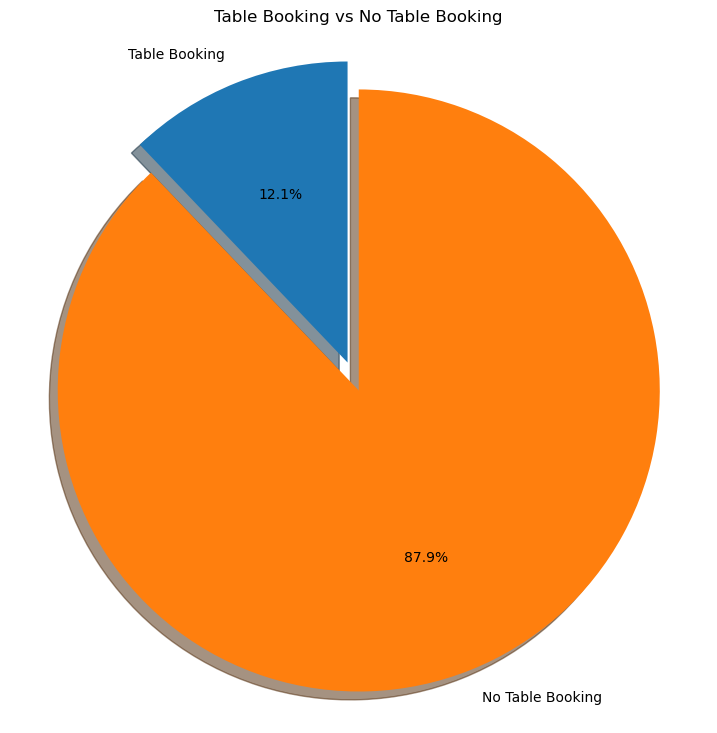

In [47]:
# Pie chart to show percentage of restaurants which allow table booking and those which don't

labels = 'Table Booking', 'No Table Booking'
sizes = [table_booking,table_nbooking]
explode = (0.1, 0)  # only "explode" the 2nd slice (i.e. 'Hogs')

fig1, ax1 = plt.subplots(figsize=(9,9))
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',shadow=True, startangle=90)
ax1.set_title("Table Booking vs No Table Booking")
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

# we can see 12.1% of restaurants allowing table booking and 87.9% don't

# -------------------------------------------------------------------------------

In [48]:
# Find out the percentage of restaurants providing online delivery

rest_od = dfm1[dfm1['Has_Online_delivery_Yes'] == 1]['Restaurant_ID'].count()
rest_nod = dfm1[dfm1['Has_Online_delivery_Yes'] == 0]['Restaurant_ID'].count()
print('Percentage of restaurants providing online delivery : {} %'.format((round(rest_od/len(dfm1),3)*100)))

Percentage of restaurants providing online delivery : 25.7 %


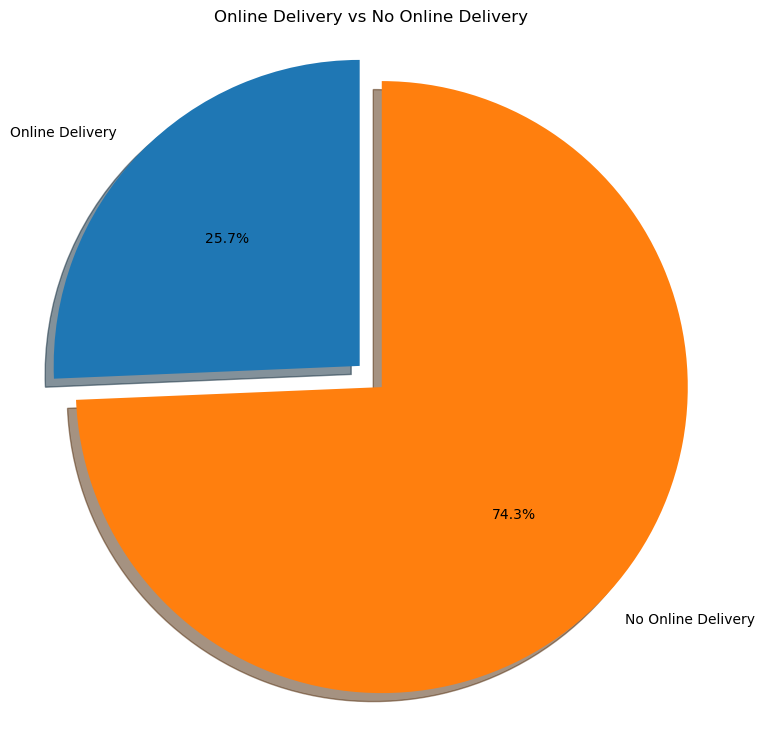

In [49]:
#pie chart to show percentages of restaurants allowing online delivery vs those which do not have online delivery
labels = 'Online Delivery','No Online Delivery'
size = [rest_od,rest_nod]
explode = (0.1,0)
fig1,ax1 = plt.subplots(figsize=(9,9))
ax1.pie(size,explode=explode,labels=labels,autopct='%1.1f%%',shadow=True,startangle=90)
ax1.set_title("Online Delivery vs No Online Delivery")
ax1.axis('equal')
plt.show()


# -------------------------------------------------------------------------------

In [50]:
# Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

rest_deliver = dfm1[dfm1['Has_Table_booking_Yes'] == 1]['Votes'].sum()
rest_ndeliver = dfm1[dfm1['Has_Table_booking_Yes'] == 0]['Votes'].sum()
print('Difference in number of votes for restaurants that deliver and dont deliver: ',abs((rest_deliver - rest_ndeliver)))

Difference in number of votes for restaurants that deliver and dont deliver:  680082


In [51]:
dc= dfm.pivot_table(index = ['Has_Online_delivery'],values = 'Votes', aggfunc = 'sum')
dc

,Votes
Has_Online_delivery,
No,979962
Yes,517914


Text(0, 0.5, 'No. of Votes')

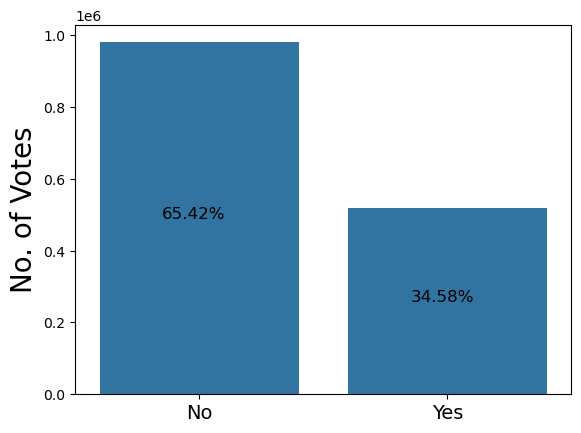

In [52]:
dc['Perc'] = (dc.Votes / dc.Votes.sum() *100).round(2)

sns.barplot(x = dc.index, y = dc.Votes,)
plt.xticks( rotation = 0, fontsize = 14)
plt.xlabel('')
for i in range(len(dc)):
 plt.annotate(str(dc.Perc.iloc[i]) + '%',xy = (i-0.15, int(dc.Votes.iloc[i]/
2)), fontsize = 12 )
plt.ylabel('No. of Votes',fontsize = 20)

# From observing the above table we can say that the difference between number of votes for restaurents that dont deliver and  deliver

# -------------------------------------------------------------------------------

In [53]:
# Performing EDA:
# 1. What are the top 10 cuisines served across cities?
# 2. What is the maximum and minimum number of cuisines that a restaurant serves? Also, which is the most served cuisine across the restaurant for each city?
# 3. What is the distribution cost across the restaurants?
# 4. How ratings are distributed among the various factors?
# 5. Explain the factors in the data that may have an effect on ratings. For example, number of cuisines, cost, delivery option, etc.

In [54]:
# What are the top 10 cuisines served across cities?

dfm["Cuisines"]

0                                    Italian, Continental
1                              Asian, Indonesian, Western
2                                         Sushi, Japanese
3                                                Japanese
4                                         French, Western
                              ...                        
9545                     Chinese, North Indian, Fast Food
9546                         Indian, Chinese, Continental
9547    Cafe, Continental, Desserts, Ice Cream, Italia...
9548                                          Street Food
9549                                Chinese, North Indian
Name: Cuisines, Length: 9550, dtype: object

In [55]:
cuisine_count = dfm["Cuisines"].str.split(", ").explode("Cuisines").value_counts()
print(cuisine_count) 
top_cuisine = cuisine_count.head(10)
top_cuisine

Cuisines
North Indian         3959
Chinese              2735
Fast Food            1986
Mughlai               995
Italian               763
                     ... 
Gourmet Fast Food       1
Irish                   1
Peruvian                1
Mineira                 1
Bubble Tea              1
Name: count, Length: 146, dtype: int64


Cuisines
North Indian    3959
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          763
Bakery           745
Continental      735
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

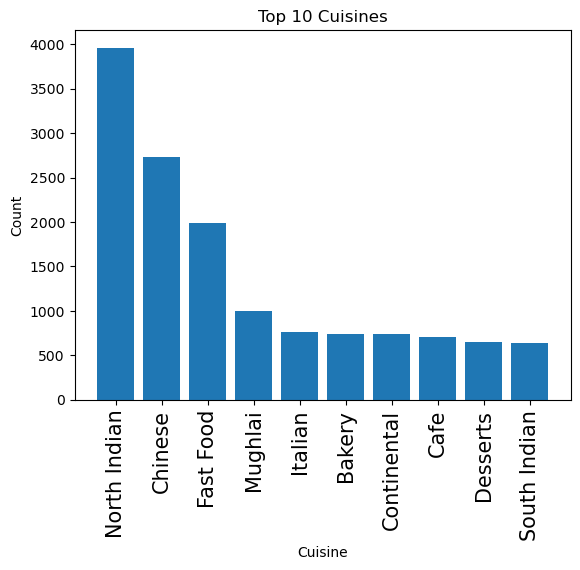

In [56]:
plt.bar(top_cuisine.index , top_cuisine.values)
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.title("Top 10 Cuisines")
plt.xticks(size = 15)
plt.xticks(rotation = 90)
plt.show()

# -------------------------------------------------------------------------------

In [57]:
# What is the maximum and minimum no. of cuisines that a restaurant serves? & what is the relationship between No. of cuisines served and Ratings?
dfm['no_cuisines']=dfm.Cuisines.str.split(',').apply(len)
dfm['no_cuisines']


0       2
1       3
2       2
3       1
4       2
       ..
9545    3
9546    3
9547    6
9548    1
9549    2
Name: no_cuisines, Length: 9550, dtype: int64

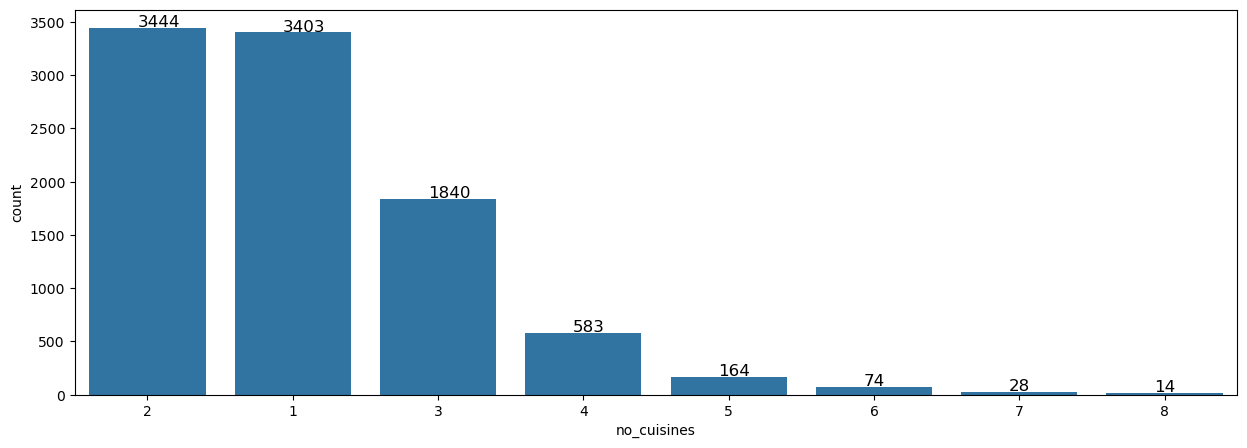

In [58]:
plt.figure(figsize = (15,5))
vc = dfm.no_cuisines.value_counts()
sns.countplot(x='no_cuisines', data=dfm, order = vc.index)
for i in range(len(vc)):
    plt.annotate(vc.iloc[i], xy = (i-0.07,vc.iloc[i]+10), fontsize = 12)
plt.show()


# the maximum no of cuisines served by a single restaurant is 8
# most of the restaurant are serving atleast 2 or 1 cuisine


# -------------------------------------------------------------------------------

In [59]:
# How ratings are distributed among the various factors?
max_rate = dfm.sort_values(by='Aggregate_rating',ascending=False).groupby(['Country','City'],as_index=False).first()
#highest rating restaurants

min_rate = dfm.sort_values(by='Aggregate_rating',ascending=False).groupby(['Country','City'],as_index=False).last()
#lowest rating restaurants

df_max=max_rate[['Country','City','Restaurant_Name','Aggregate_rating']] #new dataframe created for high rated restaurants

df_min=min_rate[['Country','City','Restaurant_Name','Aggregate_rating']] #new dataframe created for low rated restaurants

rating_rest=df_max.merge(df_min,left_on='City',right_on='City',how='inner') #merge into single dataframe

rating_rest

,Country_x,City,Restaurant_Name_x,Aggregate_rating_x,Country_y,Restaurant_Name_y,Aggregate_rating_y
0,Australia,Armidale,Whitebull Hotel,3.5,Australia,Whitebull Hotel,3.5
1,Australia,Balingup,Taste of Balingup,3.2,Australia,Taste of Balingup,3.2
2,Australia,Beechworth,Bridge Road Brewers,4.6,Australia,Bridge Road Brewers,4.6
3,Australia,Dicky Beach,The Giggling Goat,3.6,Australia,The Giggling Goat,3.6
4,Australia,East Ballina,The Belle General,4.1,Australia,The Belle General,4.1
...,...,...,...,...,...,...,...
136,United States,Valdosta,Smok'n Pig B-B-Q,4.1,United States,El Toreo Mexican Restaurant,3.1
137,United States,Vernonia,Blue House Cafe,4.3,United States,Blue House Cafe,4.3
138,United States,Waterloo,Four Queens Dairy Cream,3.9,United States,Masala Grill & Coffee House,3.2
139,United States,Weirton,Theo Yianni's Authentic Greek Restaurant,3.9,United States,Theo Yianni's Authentic Greek Restaurant,3.9


In [60]:
rating_rest.drop(columns='Country_y',axis=1,inplace=True)
rating_rest.columns = ['Country','City','Highest Rated Restaurant','Rating Max','Lowest Rated Restaurant','Rating Min']
rating_rest


,Country,City,Highest Rated Restaurant,Rating Max,Lowest Rated Restaurant,Rating Min
0,Australia,Armidale,Whitebull Hotel,3.5,Whitebull Hotel,3.5
1,Australia,Balingup,Taste of Balingup,3.2,Taste of Balingup,3.2
2,Australia,Beechworth,Bridge Road Brewers,4.6,Bridge Road Brewers,4.6
3,Australia,Dicky Beach,The Giggling Goat,3.6,The Giggling Goat,3.6
4,Australia,East Ballina,The Belle General,4.1,The Belle General,4.1
...,...,...,...,...,...,...
136,United States,Valdosta,Smok'n Pig B-B-Q,4.1,El Toreo Mexican Restaurant,3.1
137,United States,Vernonia,Blue House Cafe,4.3,Blue House Cafe,4.3
138,United States,Waterloo,Four Queens Dairy Cream,3.9,Masala Grill & Coffee House,3.2
139,United States,Weirton,Theo Yianni's Authentic Greek Restaurant,3.9,Theo Yianni's Authentic Greek Restaurant,3.9


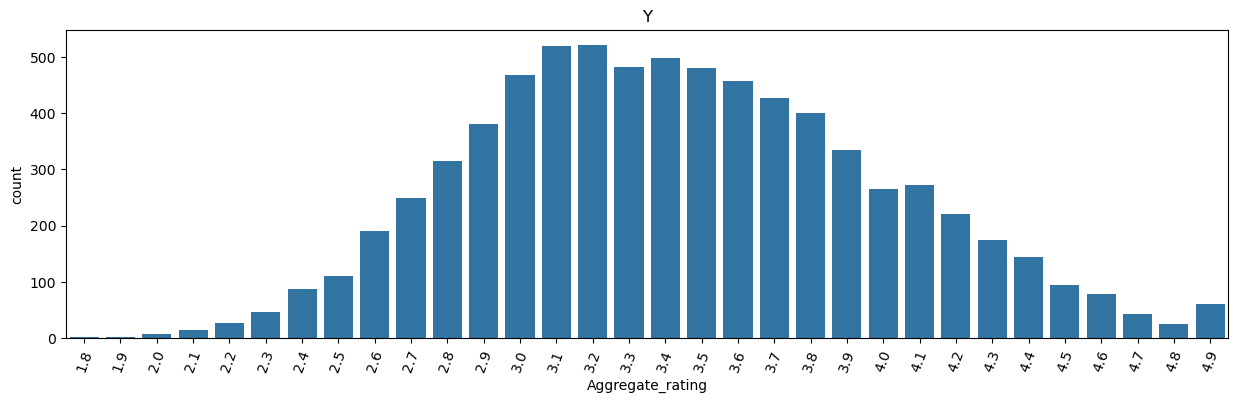

In [61]:
#Explore how ratings are distributed overall.

plt.figure( figsize = (15, 4))
sns.countplot(x='Aggregate_rating', data = dfm[dfm.Aggregate_rating !=0])
plt.tick_params('x', rotation = 70)
plt.title('Y')
plt.show()

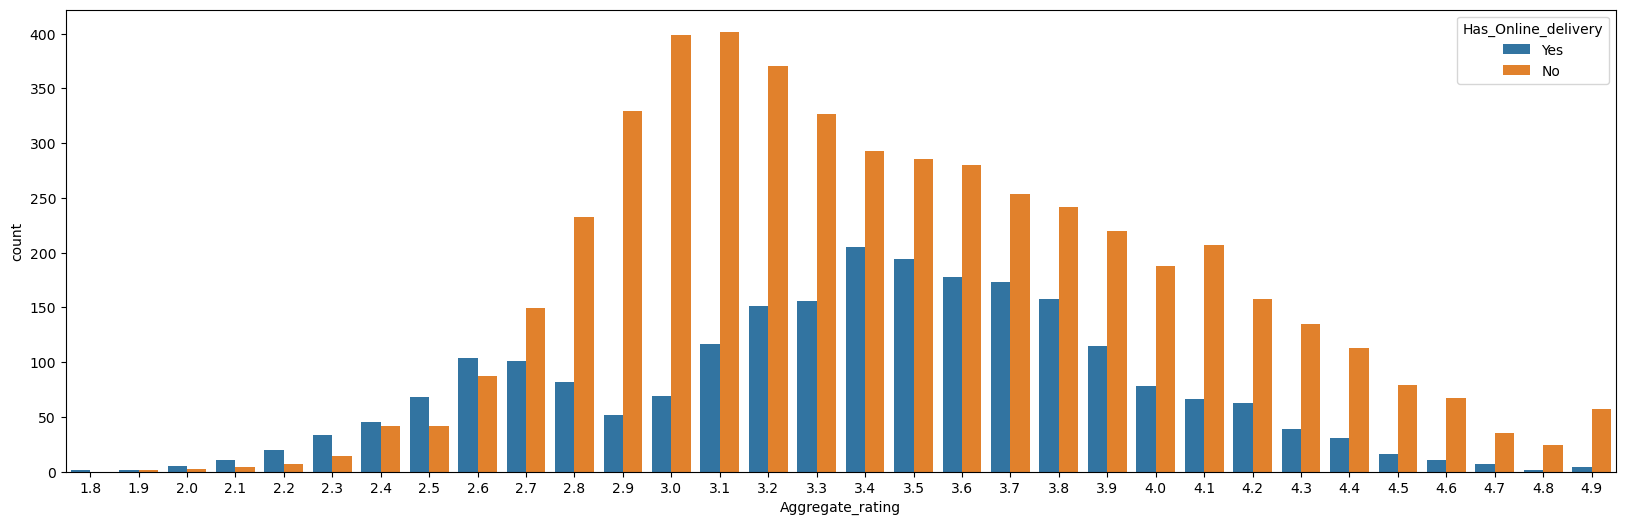

In [62]:
# Explain the factors in the data that may have an effect on ratings. For example, number of cuisines, cost, delivery option, etc.
# Rating Vs Delevery Options(Has_Online_delivery, Yes, No)



plt.figure(figsize=(20,6))
sns.countplot(data=dfm[dfm.Aggregate_rating !=0],x='Aggregate_rating',hue='Has_Online_delivery')
plt.show()


In [63]:
#From observing the above chart we can say  that the delevery options can be a factor to decide the rating of restaurent.

In [64]:
# No of Cuisines vs Rating

dfm['Rating_cat'] = dfm['Aggregate_rating'].round(0).astype(int)
fusion_rate = dfm.loc[dfm.Aggregate_rating >0,['no_cuisines', 'Rating_cat','Aggregate_rating']].copy()
fusion_rate

,no_cuisines,Rating_cat,Aggregate_rating
0,2,4,4.1
1,3,5,4.6
2,2,5,4.9
3,1,4,4.2
4,2,4,4.3
...,...,...,...
9545,3,4,4.3
9546,3,4,3.6
9547,6,4,3.9
9548,1,4,3.8


<Axes: xlabel='no_cuisines', ylabel='Aggregate_rating'>

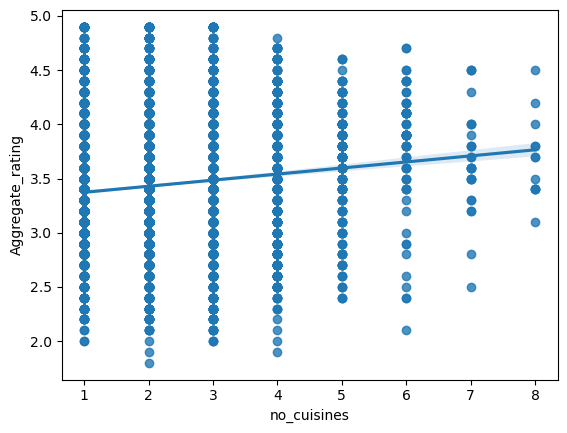

In [65]:
sns.regplot(x='no_cuisines',y='Aggregate_rating',data=fusion_rate)
#Number of cuisines is not a good factor to decide the rating of a restaurant


In [66]:
fusion_rate[['no_cuisines', 'Aggregate_rating']].corr()


,no_cuisines,Aggregate_rating
no_cuisines,1.000000,0.115067
Aggregate_rating,0.115067,1.000000


<Axes: xlabel='no_cuisines', ylabel='Aggregate_rating'>

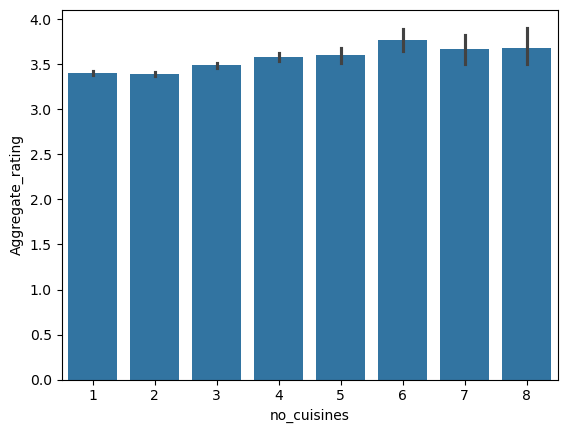

In [67]:
sns.barplot(x='no_cuisines',y='Aggregate_rating',data=fusion_rate)


In [68]:
#From the above graphs we can observe that the number of cuisines and Aggregate_rating has positive corelation. 
# We also observe that higher the number of cuisines higher the rating. 


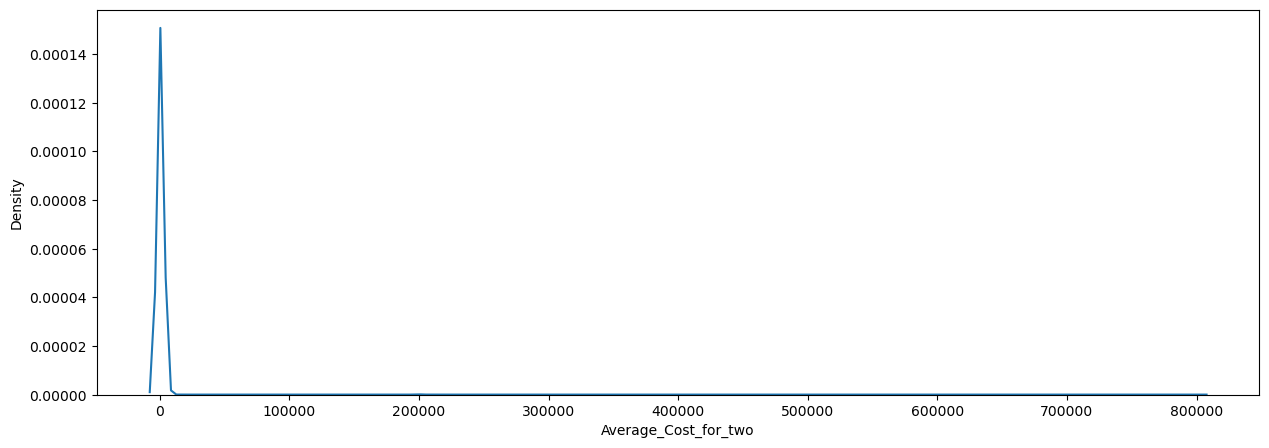

In [69]:
# Overall Cost Destribution


plt.figure(figsize = (15,5))
sns.kdeplot(dfm[dfm.Average_Cost_for_two != 0].Average_Cost_for_two)
plt.show()

In [70]:
# Discuss the cost(Average_Cost_for_two) vs rating



dfm['Average_Cost_for_two_cat']= pd.cut(dfm[dfm.Average_Cost_for_two != 0].Average_Cost_for_two,
bins = [0, 200, 500, 1000, 3000, 5000,10000],
labels = ['<=200', '<=500', '<=1000', '<=3000', '<=5000', '<=10000'])

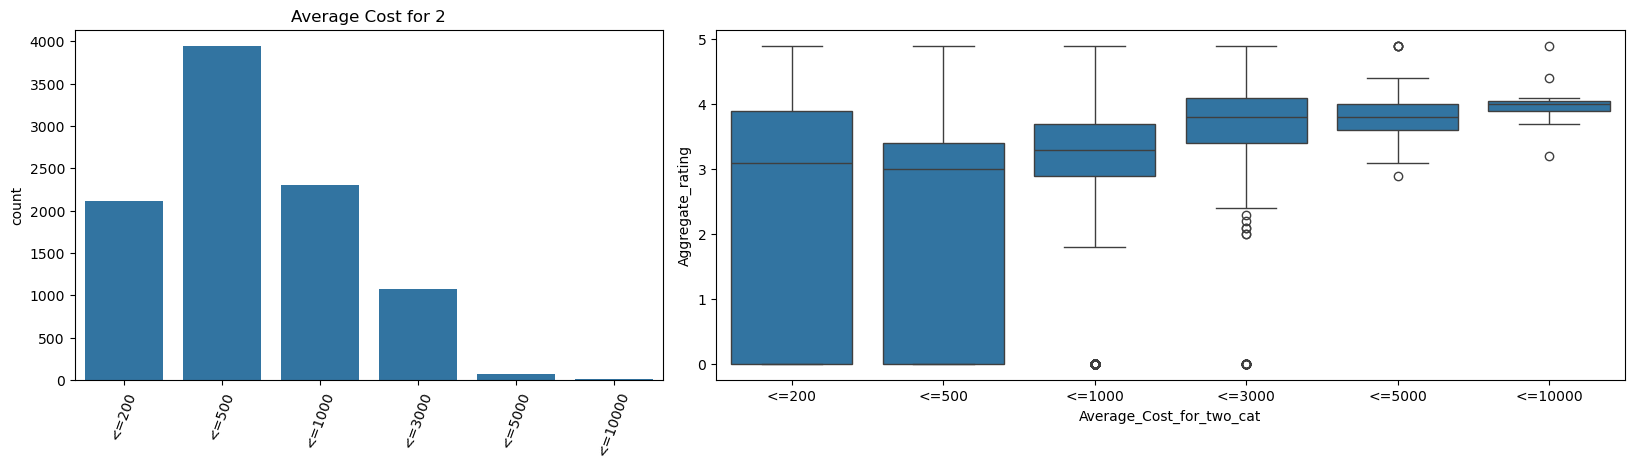

In [71]:
f = plt.figure(figsize = (20,10))
ax = plt.subplot2grid((2,5), (0,0),colspan = 2)
sns.countplot(x=dfm['Average_Cost_for_two_cat'], ax = ax)
ax.set_title('Average Cost for 2')
ax.set_xlabel('')
ax.tick_params('x', rotation = 70)
ax = plt.subplot2grid((2,5), (0,2), colspan = 3)
sns.boxplot(x = 'Average_Cost_for_two_cat', y = 'Aggregate_rating', data =dfm, ax = ax)
plt.show()

In [72]:
#From Observing the above graph we can say that as the average cost for 2 increases the aggregate rating also increases

# # Price Range Vs Rating



count = dfm['Price_range'].value_counts().reset_index()
count.columns = ['Price_range', 'Count']


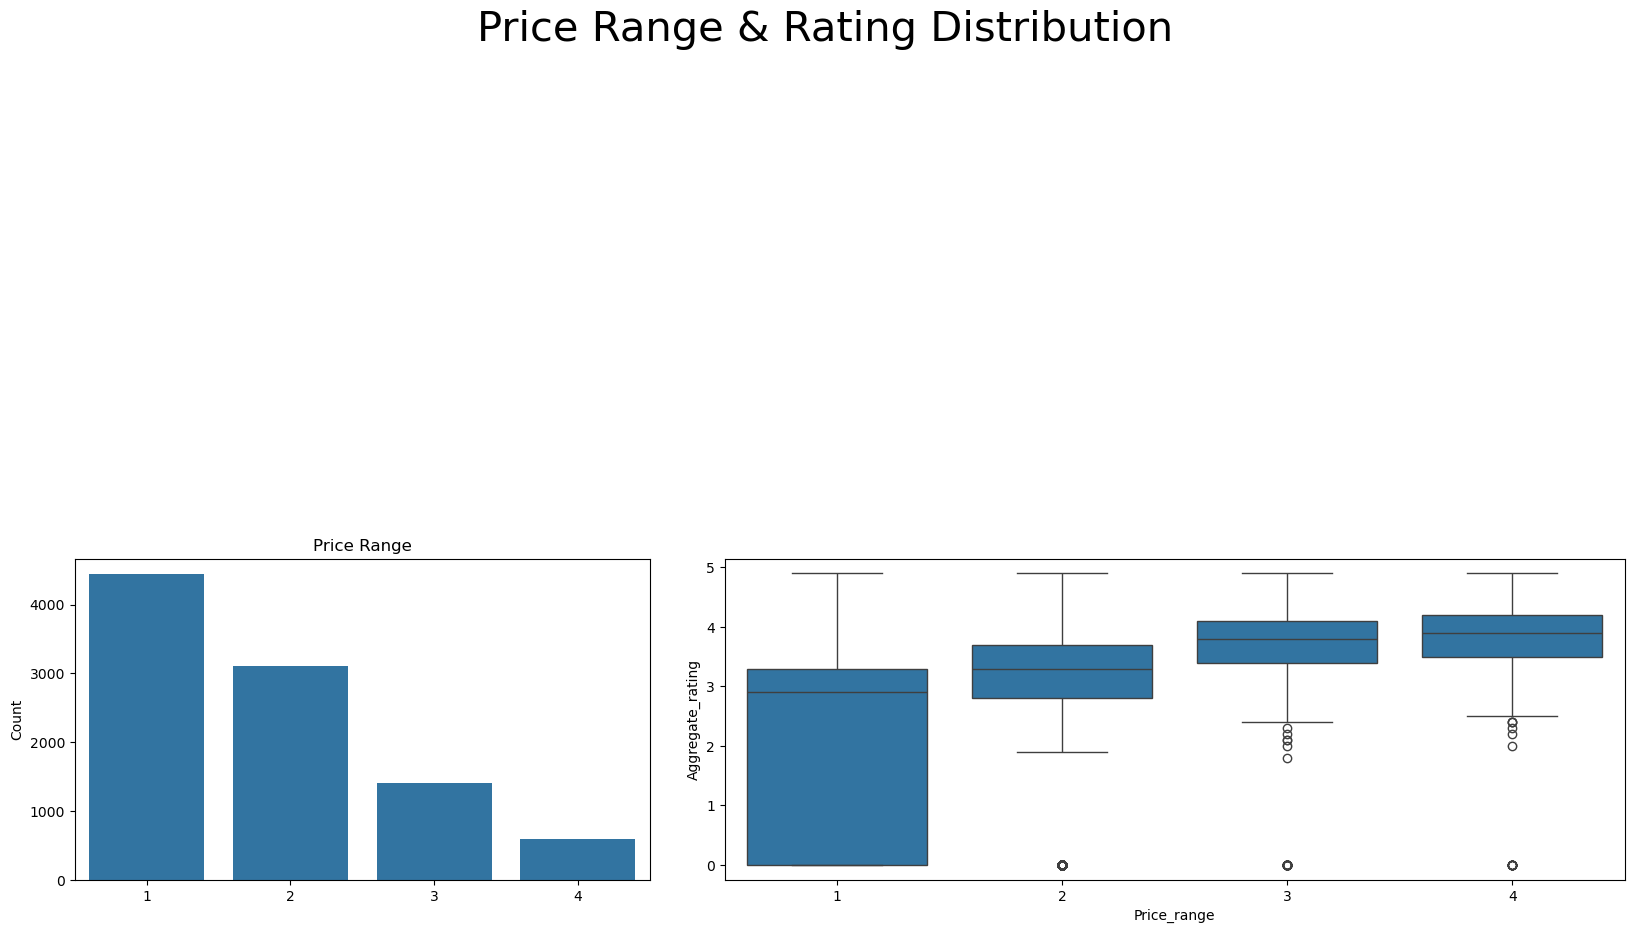

In [73]:
f = plt.figure(figsize = (20,10))
ax = plt.subplot2grid((2,5), (1,0),colspan = 2)
sns.barplot(x = 'Price_range', y = 'Count', data = count, ax=ax)
ax.set_title('Price Range')
ax.set_xlabel('')
ax = plt.subplot2grid((2,5), (1,2), colspan = 3)
sns.boxplot(x='Price_range', y ='Aggregate_rating', data = dfm, ax = ax)
plt.subplots_adjust(wspace = 0.3, hspace = 0.4,)
plt.suptitle('Price Range & Rating Distribution', size = 30)
plt.show()

,Votes,Aggregate_rating
Votes,1.000000,0.313598
Aggregate_rating,0.313598,1.000000


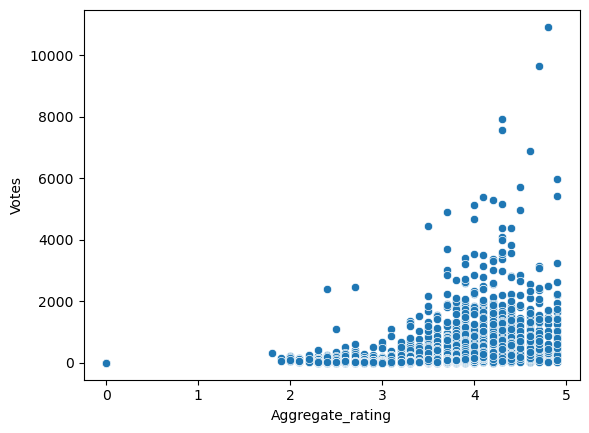

In [74]:
# Aggregate Rating vs Votes


sns.scatterplot(data=dfm,x='Aggregate_rating',y='Votes')



dfm[['Votes','Aggregate_rating']].corr()


# # We see that there is no single variable that affects the rating strongly, however table booking, 
#online delivery, avg price for two and price range, number of votes do play a part in affecting the rating of a restaurant.

In [75]:
# Conclusion : India has the Heighest Number of Restaurents with 8651 Restaurants 
# We observe that in India ,New Delhi has maximum number of Restaurants
# Cafe Coffe day has most national prsesence
# 12.1% of restaurants allowing table booking and 87.9% don't
# 34.58% Restaurants have vote they deliver and 65.42 don't
# North Indian, Chinese, Fast Food, Mughlai, Italian, Bakery, Continental, Cafe ,Desserts , South Indian these are top cuision served by restaurants
# the maximum no of cuisines served by a single restaurant is 8
# most of the restaurant are serving atleast 2 or 1 cuisine
# online delivery, avg price for two and price range, number of votes do play a part in affecting the rating of a restaurant.